<a href="https://colab.research.google.com/github/LeelaMadhuriDumpa/Projects-with-Deep-learning/blob/main/Brain_tumor_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
!pip install kagglehub

In [ ]:
import kagglehub
import os
# Download dataset
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")
print("Path to dataset files:", path)
# See what's inside
print(os.listdir(path))

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection
['no', 'yes', 'brain_tumor_dataset']


In [ ]:
import os

base_path = "/kaggle/input/brain-mri-images-for-brain-tumor-detection"

yes_path = os.path.join(base_path, "yes")
no_path = os.path.join(base_path, "no")

print("Tumor images:", len(os.listdir(yes_path)))
print("No Tumor images:", len(os.listdir(no_path)))

Tumor images: 155
No Tumor images: 98


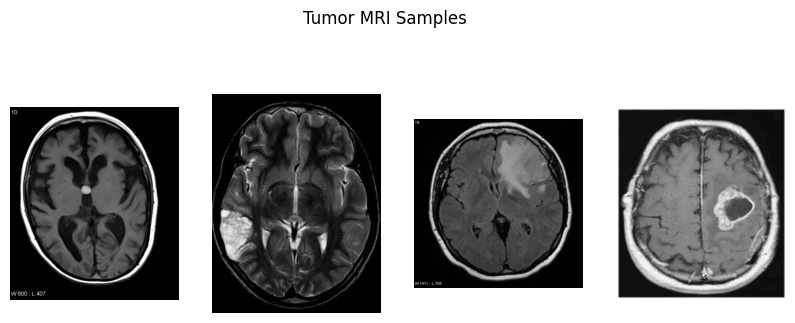

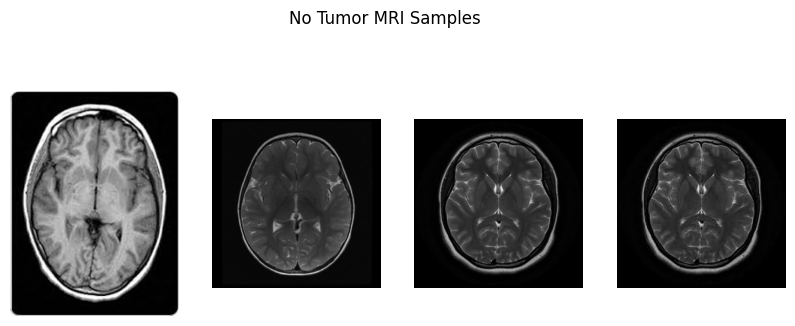

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_samples(folder, title):
    images = os.listdir(folder)
    plt.figure(figsize=(10,4))

    for i in range(4):
        img = Image.open(os.path.join(folder, random.choice(images)))
        plt.subplot(1,4,i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

show_samples(yes_path, "Tumor MRI Samples")
show_samples(no_path, "No Tumor MRI Samples")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import os
import shutil

IMG_SIZE = 128
BATCH_SIZE = 16
DATA_DIR = "/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

In [ ]:
import os
import shutil
import random

base_dir = "/kaggle/working/brain_split"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

classes = ["yes", "no"]

# Create folders
for folder in [train_dir, val_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# Split dataset
for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    train_end = int(0.7 * len(images))
    val_end = int(0.85 * len(images))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    os.path.join(train_dir,cls,img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    os.path.join(val_dir,cls,img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path,img),
                    os.path.join(test_dir,cls,img))

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 235 images belonging to 2 classes.
Found 71 images belonging to 2 classes.
Found 75 images belonging to 2 classes.


In [ ]:
print(train_data)
print(val_data)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.6446 - loss: 0.8673

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 801ms/step - accuracy: 0.6450 - loss: 0.8621 - val_accuracy: 0.8028 - val_loss: 0.6054
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6716 - loss: 0.6345

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.6708 - loss: 0.6333 - val_accuracy: 0.7606 - val_loss: 0.5114
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7509 - loss: 0.5352

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.7505 - loss: 0.5355 - val_accuracy: 0.8169 - val_loss: 0.4345
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.6863 - loss: 0.6419 - val_accuracy: 0.8028 - val_loss: 0.4717
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7421 - loss: 0.5994

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7894 - loss: 0.4481 - val_accuracy: 0.8592 - val_loss: 0.3288
Epoch 19/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8491 - loss: 0.3889 - val_accuracy: 0.8451 - val_loss: 0.3496
Epoch 20/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7800 - loss: 0.4879

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.7812 - loss: 0.4862 - val_accuracy: 0.8451 - val_loss: 0.3243
Epoch 21/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8534 - loss: 0.3865

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.8509 - loss: 0.3890 - val_accuracy: 0.8592 - val_loss: 0.3059
Epoch 22/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8187 - loss: 0.4326 - val_accuracy: 0.8732 - val_loss: 0.3408
Epoch 23/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8501 - loss: 0.4142

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.8499 - loss: 0.4131 - val_accuracy: 0.8310 - val_loss: 0.3024
Epoch 24/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8443 - loss: 0.4224 - val_accuracy: 0.8169 - val_loss: 0.3347
Epoch 25/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8215 - loss: 0.4196 - val_accuracy: 0.8310 - val_loss: 0.3348
Epoch 26/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8423 - loss: 0.4069 - val_accuracy: 0.8592 - val_loss: 0.3158
Epoch 27/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8924 - loss: 0.3539 - val_accuracy: 0.8451 - val_loss: 0.3061
Epoch 28/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8300 - loss: 0.3341

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.8303 - loss: 0.3350 - val_accuracy: 0.8451 - val_loss: 0.2667
Epoch 29/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.8213 - loss: 0.4066 - val_accuracy: 0.8732 - val_loss: 0.3491
Epoch 30/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8585 - loss: 0.3437 - val_accuracy: 0.8873 - val_loss: 0.2696


In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.8382978439331055
Final Validation Accuracy: 0.8873239159584045


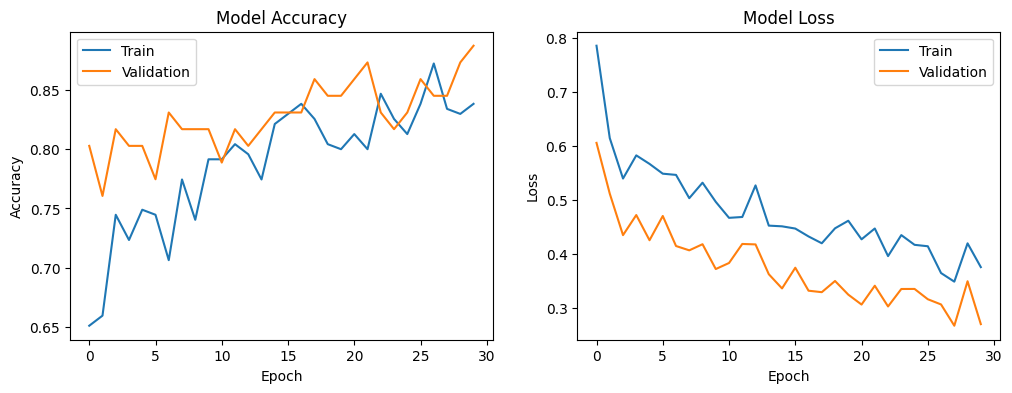

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
Prediction value: [[0.9560615]]
Tumor Detected


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

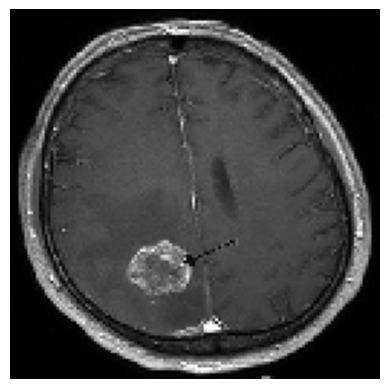

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import random

# Pick random tumor image
img_path = os.path.join(yes_path, random.choice(os.listdir(yes_path)))

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction value:", prediction)

if prediction[0][0] > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

plt.imshow(img)
plt.axis("off")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions for validation data
val_predictions = model.predict(val_data)
val_predictions = (val_predictions > 0.5).astype(int)

# True labels
true_labels = val_data.classes

# Confusion matrix
cm = confusion_matrix(true_labels, val_predictions)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, val_predictions))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
Confusion Matrix:
[[12 16]
 [21 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.43      0.39        28
           1       0.58      0.51      0.54        43

    accuracy                           0.48        71
   macro avg       0.47      0.47      0.47        71
weighted avg       0.49      0.48      0.48        71



In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop_tl = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_tl = ModelCheckpoint(
    "best_transfer_model.h5",
    monitor="val_loss",
    save_best_only=True
)

history_tl = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop_tl, checkpoint_tl]
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.5535 - loss: 0.7430

15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5585 - loss: 0.7362 - val_accuracy: 0.8732 - val_loss: 0.3711
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8072 - loss: 0.4497

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.8068 - loss: 0.4486 - val_accuracy: 0.9014 - val_loss: 0.3049
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8362 - loss: 0.3564

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.8369 - loss: 0.3565 - val_accuracy: 0.9155 - val_loss: 0.2851
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8707 - loss: 0.2831

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.8710 - loss: 0.2831 - val_accuracy: 0.9155 - val_loss: 0.2462
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8966 - loss: 0.2856

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.9376 - loss: 0.1695 - val_accuracy: 0.9155 - val_loss: 0.1493
Epoch 15/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8970 - loss: 0.2067

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.8976 - loss: 0.2073 - val_accuracy: 0.9296 - val_loss: 0.1475
Epoch 16/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9518 - loss: 0.1444 - val_accuracy: 0.9014 - val_loss: 0.1524
Epoch 17/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9657 - loss: 0.1379 - val_accuracy: 0.9155 - val_loss: 0.1729
Epoch 18/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9734 - loss: 0.1243 - val_accuracy: 0.9155 - val_loss: 0.1528
Epoch 19/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9668 - loss: 0.1091

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9660 - loss: 0.1103 - val_accuracy: 0.9296 - val_loss: 0.1401
Epoch 20/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9364 - loss: 0.1650 - val_accuracy: 0.9296 - val_loss: 0.1458
Epoch 21/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9465 - loss: 0.1552 - val_accuracy: 0.9437 - val_loss: 0.1454
Epoch 22/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9620 - loss: 0.1096

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.9617 - loss: 0.1094 - val_accuracy: 0.9577 - val_loss: 0.1191
Epoch 23/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9696 - loss: 0.0959

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.9691 - loss: 0.0972 - val_accuracy: 0.9577 - val_loss: 0.1087
Epoch 24/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9609 - loss: 0.0798 - val_accuracy: 0.9296 - val_loss: 0.1215
Epoch 25/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9659 - loss: 0.1052 - val_accuracy: 0.9437 - val_loss: 0.1577
Epoch 26/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9205 - loss: 0.2048 - val_accuracy: 0.9296 - val_loss: 0.1609
Epoch 27/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9300 - loss: 0.1402 - val_accuracy: 0.9577 - val_loss: 0.1270
Epoch 28/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9745 - loss: 0.1034 - val_accuracy: 0.9437 - val_loss: 0.1258


In [ ]:
print("Final Training Accuracy:", history_tl.history['accuracy'][-1])
print("Final Validation Accuracy:", history_tl.history['val_accuracy'][-1])

Final Training Accuracy: 0.978723406791687
Final Validation Accuracy: 0.9436619877815247


In [ ]:
print("Evaluating CNN...")
cnn_loss, cnn_acc = model.evaluate(test_data)
print("CNN Test Accuracy:", cnn_acc)

print("\nEvaluating Transfer Learning Model...")
tl_loss, tl_acc = transfer_model.evaluate(test_data)
print("Transfer Learning Test Accuracy:", tl_acc)

Evaluating CNN...
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8576 - loss: 0.3250

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.8539 - loss: 0.3404
CNN Test Accuracy: 0.8533333539962769

Evaluating Transfer Learning Model...
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 990ms/step - accuracy: 0.9301 - loss: 0.1509
Transfer Learning Test Accuracy: 0.9466666579246521


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# CNN Predictions
cnn_preds = model.predict(test_data)
cnn_preds = (cnn_preds > 0.5).astype(int)

# Transfer Learning Predictions
tl_preds = transfer_model.predict(test_data)
tl_preds = (tl_preds > 0.5).astype(int)

true_labels = test_data.classes

print("===== CNN Classification Report =====")
print(classification_report(true_labels, cnn_preds))

print("\n===== Transfer Learning Classification Report =====")
print(classification_report(true_labels, tl_preds))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
===== CNN Classification Report =====
              precision    recall  f1-score   support

           0       0.77      0.90      0.83        30
           1       0.93      0.82      0.87        45

    accuracy                           0.85        75
   macro avg       0.85      0.86      0.85        75
weighted avg       0.86      0.85      0.85        75


===== Transfer Learning Classification Report =====
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.96      0.96      0.96        45

    accuracy                           0.95        75
   macro avg       0.94      0.94      0.94        75
weighted avg       0.95      0.95      0.95        75



In [ ]:
from sklearn.metrics import classification_report

# CNN
cnn_report = classification_report(true_labels, cnn_preds, output_dict=True)

# Transfer Learning
tl_report = classification_report(true_labels, tl_preds, output_dict=True)

In [ ]:
cnn_accuracy = cnn_report['accuracy']
cnn_f1 = cnn_report['1']['f1-score']   # class 1 = tumor

tl_accuracy = tl_report['accuracy']
tl_f1 = tl_report['1']['f1-score']

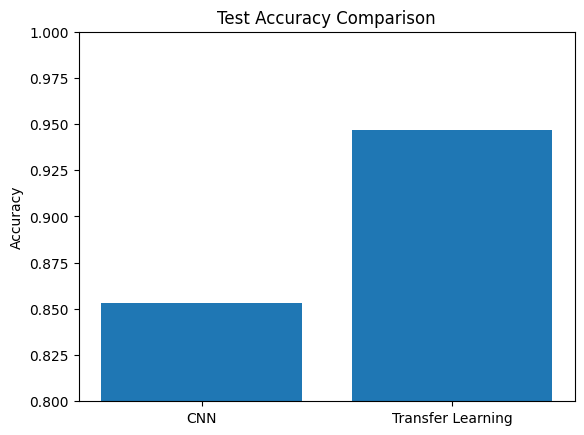

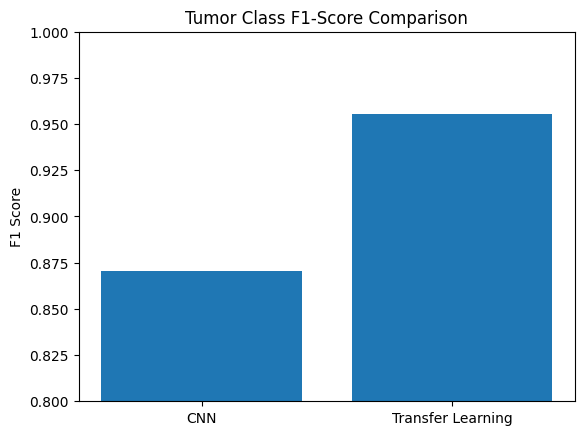

In [ ]:
import matplotlib.pyplot as plt

models = ['CNN', 'Transfer Learning']
accuracy = [cnn_accuracy, tl_accuracy]
f1_scores = [cnn_f1, tl_f1]

plt.figure()
plt.bar(models, accuracy)
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.savefig("accuracy_comparison.png")
plt.show()

plt.figure()
plt.bar(models, f1_scores)
plt.title("Tumor Class F1-Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0.8, 1.0)
plt.savefig("f1_comparison.png")
plt.show()

In [ ]:
from google.colab import files
files.download("accuracy_comparison.png")
files.download("f1_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


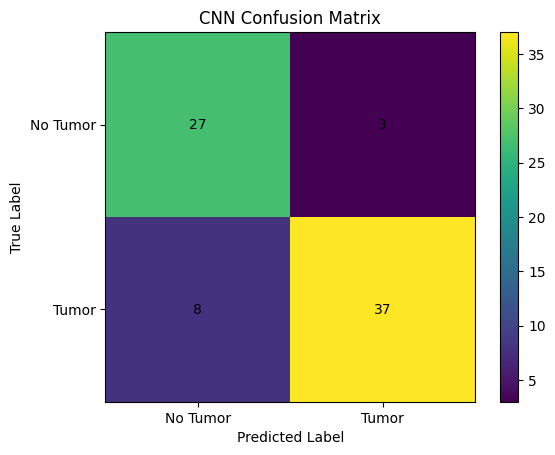

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# CNN Predictions
cnn_preds = model.predict(test_data)
cnn_preds = (cnn_preds > 0.5).astype(int)

true_labels = test_data.classes

cm_cnn = confusion_matrix(true_labels, cnn_preds)

plt.figure()
plt.imshow(cm_cnn)
plt.title("CNN Confusion Matrix")
plt.colorbar()

classes = ["No Tumor", "Tumor"]
plt.xticks(np.arange(2), classes)
plt.yticks(np.arange(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_cnn[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("cnn_confusion_matrix.png")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


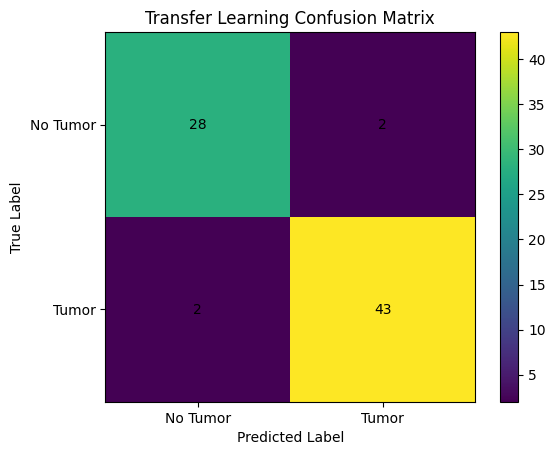

In [ ]:
# Transfer Learning Predictions
tl_preds = transfer_model.predict(test_data)
tl_preds = (tl_preds > 0.5).astype(int)

cm_tl = confusion_matrix(true_labels, tl_preds)

plt.figure()
plt.imshow(cm_tl)
plt.title("Transfer Learning Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(2), classes)
plt.yticks(np.arange(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_tl[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("transfer_confusion_matrix.png")
plt.show()

In [ ]:
from google.colab import files

files.download("cnn_confusion_matrix.png")
files.download("transfer_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>